# Aufgabe 1


Ansatz:
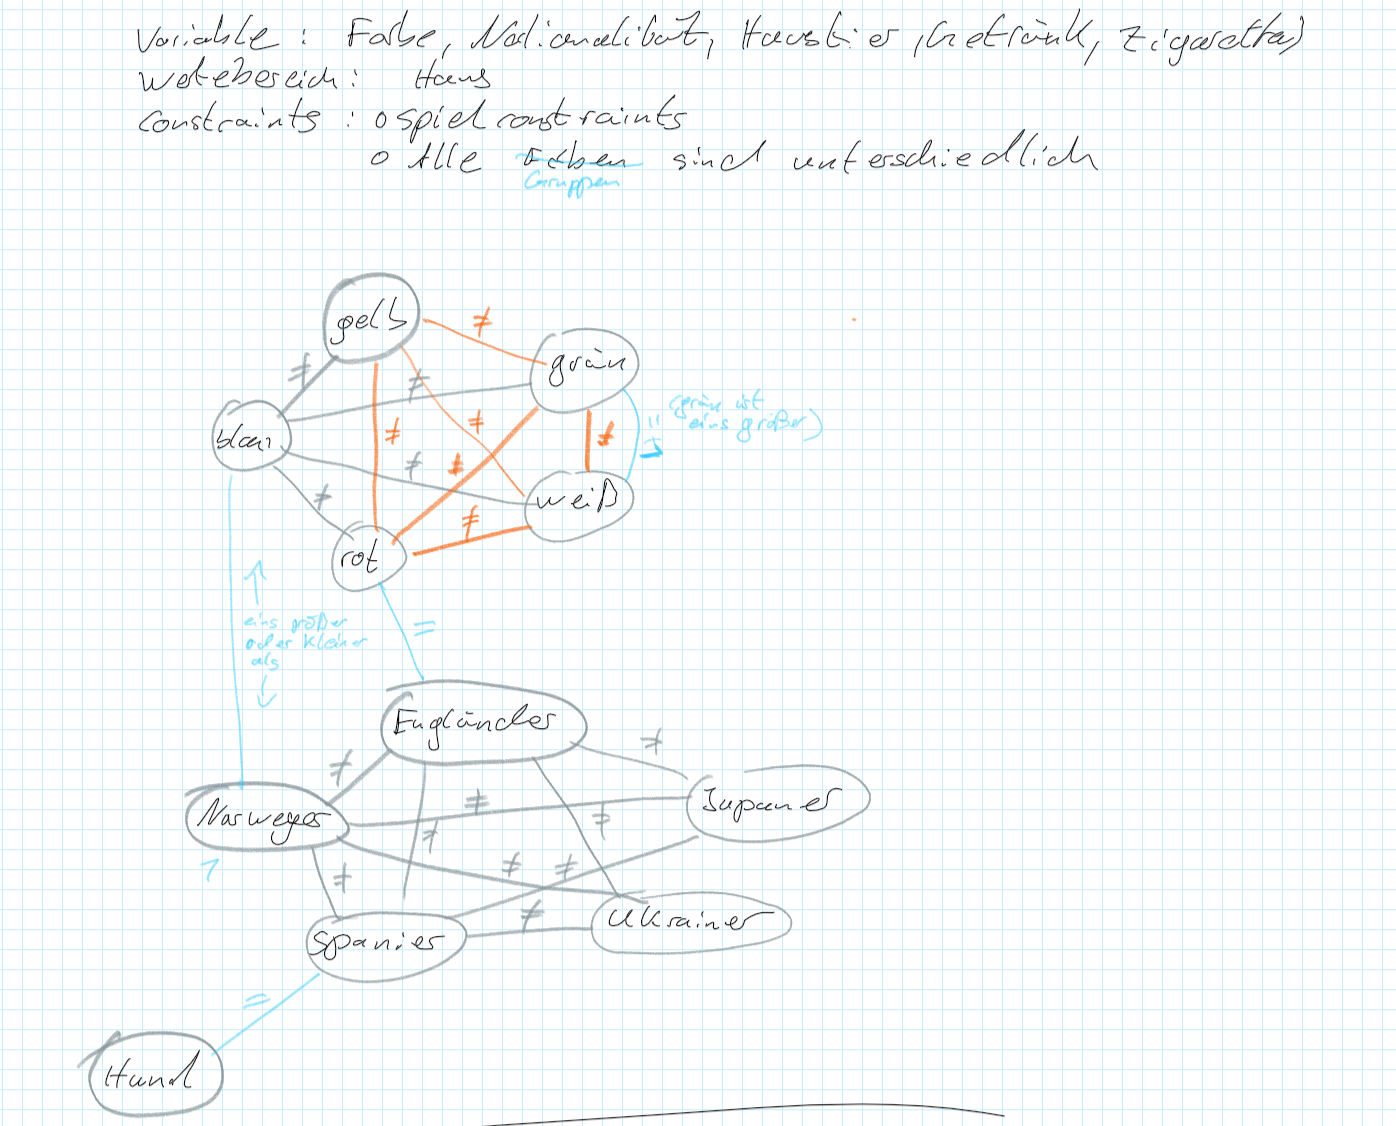

# Aufgabe 2


## Aufgabe 2.0

In [63]:

record Variable<T>(string Name, T? Value);

delegate bool VariableConstraintPredicate<T>(Variable<T> a, Variable<T> b);
record VariableConstraint<T>(string To, VariableConstraintPredicate<T> Predicate);

record VariableConfig<T>(Variable<T> Variable, VariableConstraint<T>[] Constraints);

const string Unary = "UNARY";

class CPS<T>
{
    private readonly Dictionary<string, List<VariableConstraint<T>>> _constraints;


    public CPS(IEnumerable<string> variables) 
    {
        _constraints = new Dictionary<string, List<VariableConstraint<T>>>();

        foreach (var v in variables) {
            _constraints.Add(v, []);
        }
    }

    public IEnumerable<string> Variables => _constraints.Keys;

    public CPS<T> AddConstraint(string name, VariableConstraint<T> constraint) {
        _constraints[name].Add(constraint);
        return this;
    }

    public CPS<T> AddConstraintBi(string name, VariableConstraint<T> constraint) {
        _constraints[name].Add(constraint);
        _constraints[constraint.To].Add(new VariableConstraint<T>(name, constraint.Predicate));
        return this;
    }

    public CPS<T> AddConstraintRev(string name, VariableConstraint<T> constraint) {
        _constraints[name].Add(constraint);
        // call the predicate with the second argument first, which makes sure the "name" value comes first again
        _constraints[constraint.To].Add(new VariableConstraint<T>(name, (a, b) => constraint.Predicate(b, a)));
        return this;
    }

    public CPS<T> AddConstraintRev(string name, string to, Func<T?, T?, bool> constraint) {
        _constraints[name].Add(new VariableConstraint<T>(to, (a, b) => constraint(a.Value, b.Value)));
        // call the predicate with the second argument first, which makes sure the "name" value comes first again
        _constraints[to].Add(new VariableConstraint<T>(name, (a, b) => constraint(b.Value, a.Value)));
        return this;
    }

    public CPS<T> AddConstraints(string name, IEnumerable<VariableConstraint<T>> constraint) {
        _constraints[name].AddRange(constraint);
        return this;
    }

    public CPS<T> AddUnaryConstraint(string name, Func<T?, bool> constraint) {
        _constraints[name].Add(new VariableConstraint<T>(Unary, (a, b) => constraint(a.Value)));
        return this;
    }

    public IEnumerable<VariableConstraint<T>> GetConstraints(string name) {
        return _constraints[name];
    }
}


class CPSSolver<T>  
{
    private readonly CPSSolver<T>? _base;
    private readonly CPS<T>? _baseConfig;
    private readonly T[]? _baseValues;

    public CPS<T> Config => _baseConfig ??_base!.Config;
    public T[] Values => _baseValues ?? _base!.Values;

    private readonly (string Name, T Variable) _assignment;

    public CPSSolver(CPS<T> config, IEnumerable<T> values) 
    {
        _baseConfig = config;
        _baseValues = values.ToArray();
    }

    private CPSSolver(CPSSolver<T> parent, string name, T assignment) {
        _base = parent;

        _assignment = (name, assignment);
    }


    public IEnumerable<Variable<T>> GetAssignments() 
    {
        if (_base is null)
            return [];
        return _base.GetAssignments().Append(new Variable<T>(_assignment.Name, _assignment.Variable));
    }

    public IEnumerable<string> GetUnassignedVariables() 
    {
        var variables = Config.Variables.ToList();
        foreach (var a in GetAssignments())
            variables.Remove(a.Name);
        return variables;
    }

    public bool IsCompleted() {
        return GetUnassignedVariables().Count() == 0;
    }

    public IEnumerable<string> GetVariables() => Config.Variables;

    public Variable<T> GetAssignment(string name) {
        if (GetAssignments().FirstOrDefault(x => x.Name == name) is {} a)
            return a;
        return new Variable<T>(name, default(T));
    }

    public IEnumerable<VariableConstraint<T>> GetConstraints(string name) {
        return Config.GetConstraints(name);
    }

    public CPSSolver<T> Assign(string name, T value) {
        return new CPSSolver<T>(this, name, value);
    }

    public bool Consistent(string name, T value) 
    {
        var constraints = GetConstraints(name);

        var self = new Variable<T>(name, value);
        foreach (var c in constraints) {
            var other = c.To == Unary 
                ? new Variable<T>(Unary, default(T))
                : GetAssignment(c.To);
            
            if (!c.Predicate(self, other))
            {
                return false;
            }
        }
        return true;
    }

    public IEnumerable<string> GetVariables(T value) => 
        GetAssignments()
            .Where(x => x.Value.Equals(value))
            .Select(x => x.Name);

    public IEnumerable<T> GetAvailableValues(string name) {

        var constraints = GetConstraints(name);

        foreach (var v in Values) {
            
            var conflict = false;

            var self = new Variable<T>(name, v);
            foreach (var c in constraints) {
                var other = c.To == Unary 
                    ? new Variable<T>(Unary, default(T))
                    : GetAssignment(c.To);
                
                if (!c.Predicate(self, other))
                {
                    conflict = true;
                    break;   
                }
            }

            if (!conflict)
                yield return v;
        }

    }


    public void Print() {
        foreach (var a in GetAssignments()) {
            Console.WriteLine($"{a.Name}: {a.Value}");
        }
    }

}

In [64]:
string[] colors = [
    "gelb",
    "grün",
    "weiß",
    "rot",
    "blau"
];

string[] nationality = [
    "Norweger",
    "Ukrainer",
    "Engländer",
    "Spanier",
    "Japaner"
];

string[] pet = [
    "Zebra",
    "Hund",
    "Schnecke",
    "Pferd",
    "Fuchs"
];

string[] beverage = [
    "Kaffee",
    "O-Saft",
    "Milch",
    "Tee",
    "Wasser"
];

string[] zigarette = [
    "Kools",
    "Chesterfield",
    "Old Gold",
    "Lucky Strike",
    "Parliaments"
];

int[] values = [1, 2, 3, 4, 5];

string[] variables = [..colors, ..nationality, ..pet, ..beverage, ..zigarette];
var cps = new CPS<int>(variables);


void NotEqual(CPS<int> cps, IEnumerable<string> values) {

    foreach (var c1 in values) {
        foreach (var c2 in values) {
            if (c1 == c2)
                continue;
            
            cps.AddConstraint(c1, new VariableConstraint<int>(c2, (a, b) => {
                    // Console.WriteLine($"a: {a}, b: {b}, c: {a != b}");
                    return a.Value != b.Value;
                }));
        }
    }
}

// basic not equal constraints
NotEqual(cps, colors);
NotEqual(cps, nationality);
NotEqual(cps, pet);
NotEqual(cps, beverage);
NotEqual(cps, zigarette);

bool Equal(int a, int b) => b == 0 || a == 0 || a == b;
bool NextDoor(int a, int b) => b == 0 || a == 0 || (a == (b - 1)) || (a == (b + 1));

cps.AddConstraintRev("Engländer", "rot", Equal);
cps.AddConstraintRev("Spanier", "Hund", Equal);
cps.AddConstraintRev("Kaffee", "grün", Equal);
cps.AddConstraintRev("Ukrainer", "Tee", Equal);
cps.AddConstraintRev("grün", "weiß", (a, b) => b == 0 || a == 0 || (b + 1) == a && a != 1); // grün rechts neben weiß
cps.AddConstraintRev("Old Gold", "Schnecke", Equal);
cps.AddConstraintRev("Kools", "gelb", Equal);
cps.AddUnaryConstraint("Milch", a => a == 3);       // Mittleres Haus
cps.AddUnaryConstraint("Norweger", a => a == 1);    // Erstes Haus
cps.AddConstraintRev("Chesterfield", "Fuchs", NextDoor); // nebenan
cps.AddConstraintRev("Kools", "Pferd", NextDoor);
cps.AddConstraintRev("Lucky Strike", "O-Saft", Equal);
cps.AddConstraintRev("Japaner", "Parliaments", Equal);
cps.AddConstraintRev("Norweger", "blau", NextDoor);



// var solver = new CPSSolver<int>(cps, values);

// solver = solver.Assign("grün", 1);
// solver = solver.Assign("weiß", 2);
// solver.GetAvailableValues("gelb")


In [44]:
var solver = new CPSSolver<int>(cps, values);
solver = solver.Assign("Norweger", 1);
solver = solver.Assign("Ukrainer", 2);
solver.Consistent("Spanier", 1)

False

In [45]:

var solver = new CPSSolver<int>(cps, values);
foreach (var v in variables) {
    Console.WriteLine($"{v}: [{string.Join(", ", solver.GetAvailableValues(v))}]");
}

gelb: [1, 2, 3, 4, 5]
grün: [1, 2, 3, 4, 5]
weiß: [1, 2, 3, 4, 5]
rot: [1, 2, 3, 4, 5]
blau: [1, 2, 3, 4, 5]
Norweger: [1]
Ukrainer: [1, 2, 3, 4, 5]
Engländer: [1, 2, 3, 4, 5]
Spanier: [1, 2, 3, 4, 5]
Japaner: [1, 2, 3, 4, 5]
Zebra: [1, 2, 3, 4, 5]
Hund: [1, 2, 3, 4, 5]
Schnecke: [1, 2, 3, 4, 5]
Pferd: [1, 2, 3, 4, 5]
Fuchs: [1, 2, 3, 4, 5]
Kaffee: [1, 2, 3, 4, 5]
O-Saft: [1, 2, 3, 4, 5]
Milch: [3]
Tee: [1, 2, 3, 4, 5]
Wasser: [1, 2, 3, 4, 5]
Kools: [1, 2, 3, 4, 5]
Chesterfield: [1, 2, 3, 4, 5]
Old Gold: [1, 2, 3, 4, 5]
Lucky Strike: [1, 2, 3, 4, 5]
Parliaments: [1, 2, 3, 4, 5]


In [65]:
interface IBtSearchTools<T>
{
    string GetVariable(CPSSolver<T> state);

    IEnumerable<T> GetValues(CPSSolver<T> state, string variable);

    bool Inference(CPSSolver<T> state, string variable, T value);
}

class BtSearch
{
    private readonly IBtSearchTools<int> _tools;

    private BtSearch(IBtSearchTools<int> tools) {
        _tools = tools;
    }

    public static BtSearch Search(CPSSolver<int> initial, IBtSearchTools<int> tools) 
    {
        var instance = new BtSearch(tools);
        instance.Result = instance.Search(initial);
        return instance;
    }

    public int Count { get; private set; }
    public CPSSolver<int>? Result {get; private set; }

    private CPSSolver<int>? Search(CPSSolver<int> state) {

        if (state.IsCompleted())
            return state;

        Count++;

        var variable = _tools.GetVariable(state);

        foreach (var value in _tools.GetValues(state, variable)) 
        {
            if (state.Consistent(variable, value)) {
                var newState = state.Assign(variable, value);

                if (_tools.Inference(newState, variable, value))
                {
                    if (Search(newState) is {} success)
                        return success;
                }
            
            }

        }

        return null;
    }

    public void PrintResult() {

        if (Result is null) {
            Console.WriteLine("No result found");
            Console.WriteLine($"Steps: {Count}");
        }

        var nValue = Result.GetAssignment("Norweger").Value;
        Console.WriteLine($"House: {nValue}");
        foreach (var v in Result.GetVariables(nValue))
            Console.WriteLine($"  {v}");

        nValue = Result.GetAssignment("Japaner").Value;
        Console.WriteLine($"House: {nValue}");
        foreach (var v in Result.GetVariables(nValue))
            Console.WriteLine($"  {v}");


        Console.WriteLine($"-- Steps: {Count}");
    }

}

## Aufgabe 2.1

 * EndState?
 * Hole die erste freie Variable (Später Heuristik)
 * Für jede mögliche Zuweisung
    + Ist der Wert gültig (Konsistent)
    + Überprüfe die restlichen freien Variablen Rekursiv

In [66]:

class BtSearchTools : IBtSearchTools<int> 
{
    public string GetVariable(CPSSolver<int> state) =>
        state.GetUnassignedVariables().First();

    public IEnumerable<int> GetValues(CPSSolver<int> state, string variable) => 
        state.Values;

    public bool Inference(CPSSolver<int> state, string variable, int value) => true;
}


var initialState = new CPSSolver<int>(cps, values);
var solver = BtSearch.Search(initialState, new BtSearchTools());

solver.PrintResult()


House: 1
  gelb
  Norweger
  Fuchs
  Wasser
  Kools
House: 5
  grün
  Japaner
  Zebra
  Kaffee
  Parliaments
-- Steps: 2277


## Aufgabe 2.2

Mit MRV und Gradheuristik

MRV -> Minimum remaining Values  
Gradheuristik -> erweitert MRV bei gleichstand. Überprüft, welcher Variable mehr Constraints auf offene Variablen hat

In [69]:
class MrvBtSearchTools : IBtSearchTools<int> 
{
    public string GetVariable(CPSSolver<int> state)
    {
        
        int remaining = int.MaxValue;
        List<string> variables = [];

        foreach (var v in state.GetUnassignedVariables())
        {
            var consistentValues = state.Values.Count(x => state.Consistent(v, x));

            if (consistentValues < remaining)
            {
                remaining = consistentValues;
                variables = [v];
            }
        }
        // ^^ MRV

        if (variables.Count == 1)
            return variables[0];

        Console.WriteLine("Gradheuristik");

        remaining = int.MaxValue;
        string variable = null;

        foreach (var v in variables) 
        {
            var variableConstraints = state.Config.GetConstraints(v);
            var count = variableConstraints.Select(x => state.GetAssignment(x.To)).Count(x => x.Value == 0);

            if (count < remaining)
            {
                remaining = count;
                variable = v;   
            }
        }

        return variable;
    }
        
    public IEnumerable<int> GetValues(CPSSolver<int> state, string variable) => 
        state.Values;

    public bool Inference(CPSSolver<int> state, string variable, int value) => true;
}


var initialState = new CPSSolver<int>(cps, values);
var solver = BtSearch.Search(initialState, new MrvBtSearchTools());

solver.PrintResult()

House: 1
  Norweger
  gelb
  Kools
  Wasser
  Fuchs
House: 5
  grün
  Kaffee
  Japaner
  Parliaments
  Zebra
-- Steps: 62


# Aufgabe 3

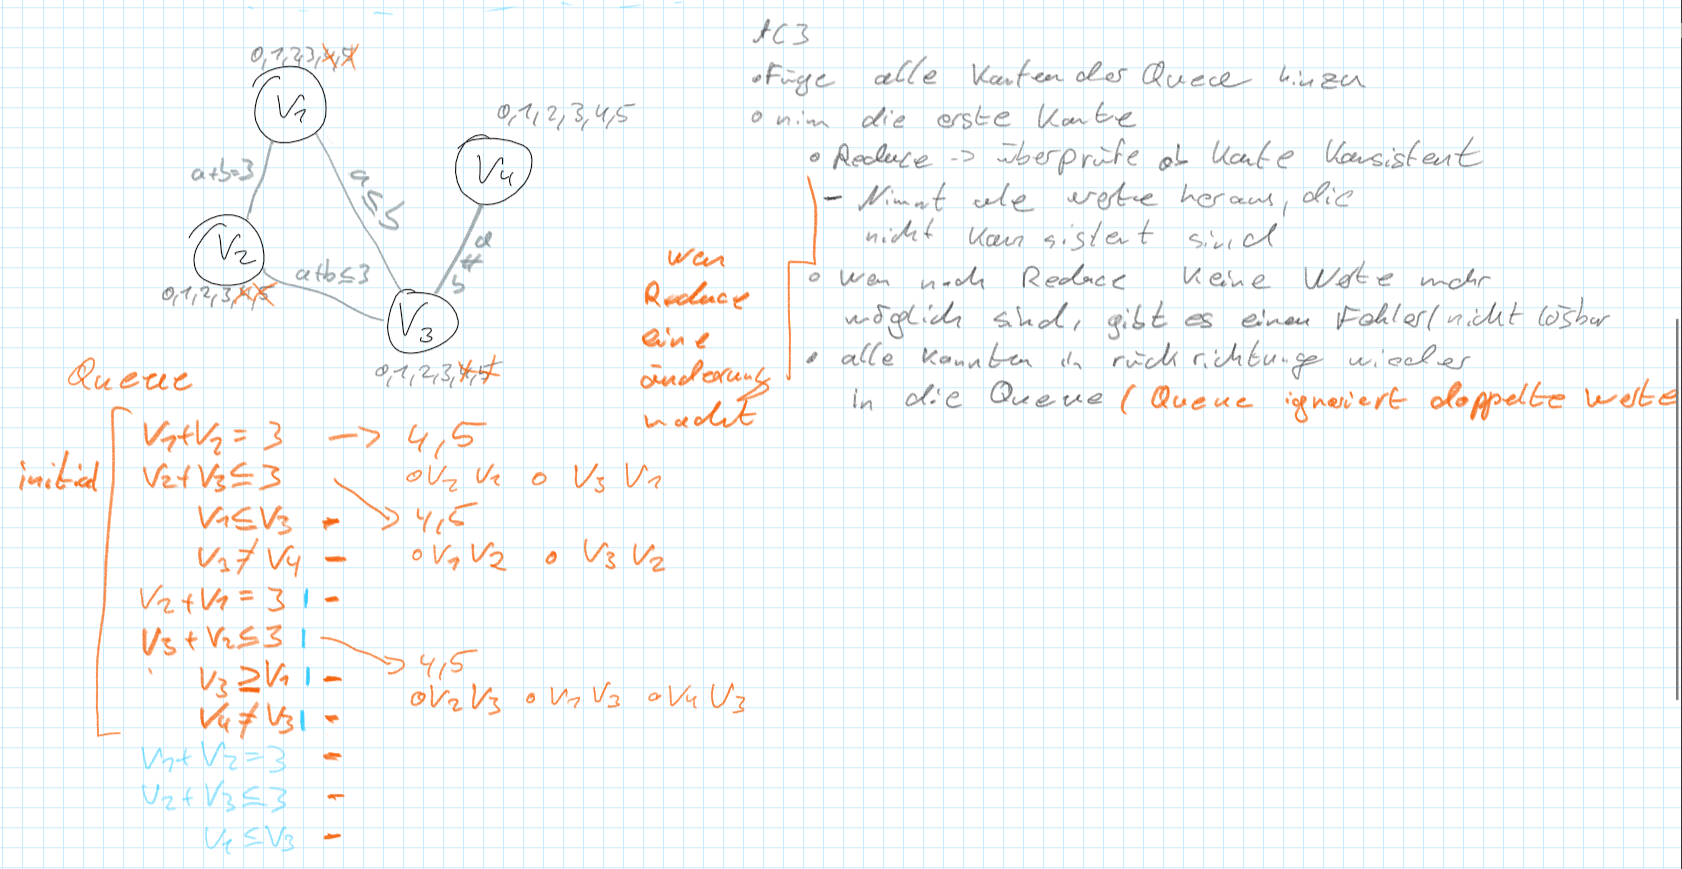


# Aufgabe 4

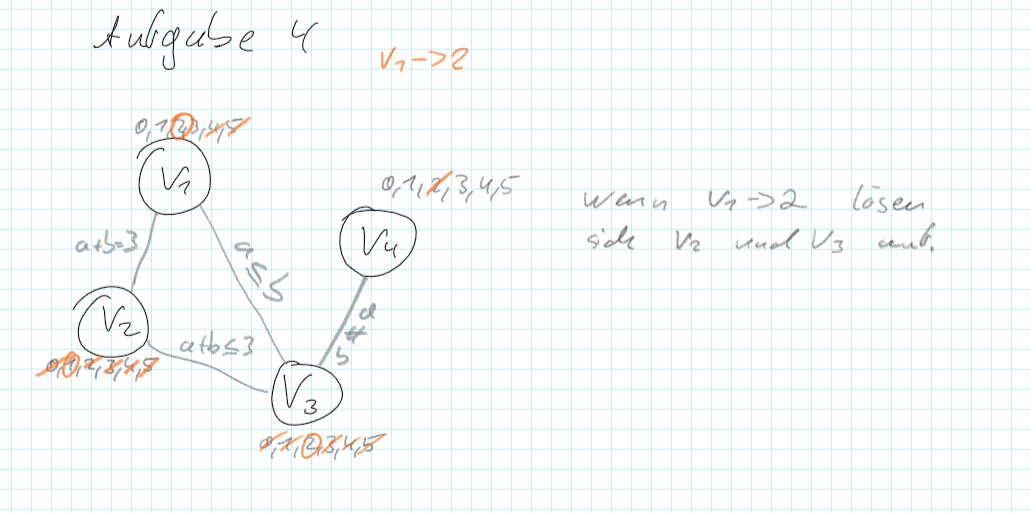

# Post mortem

Jede Person beschreibt in der ILIAS-Abgabe individuell(!) die Bearbeitung des jeweiligen Aufgabenblattes
zurückblickend mit ca. 200 bis 400 Wörtern. Gehen Sie dabei aussagekräftig und nachvollziehbar auf folgende Punkte ein: 
 (a) Zusammenfassung: Was wurde gemacht? 
 (b) Implementierungsdetails: Kurze Beschreibung besonders interessanter Aspekte der Umsetzung. 
 (c) Was war der schwierigste Teil bei der Bearbeitung? Wie haben Sie dieses Problem gelöst? 
 (d) Was haben Sie gelernt oder (besser) verstanden? 
 (e) Team: Mit wem haben Sie zusammengearbeitet? 
 (f) Link zum Repo mit der Lösung 



 * a: Die erste Aufgabe habe ich Aufgezeichnet. Allerdings habe ich nicht das vollständige Diagramm aufgeschrieben. Die erste Idee war, die Hausnummern als Knoten zu verwenden. Die {Farbe, Haustier, ...} müssten dan aber irgendwie in allen möglichen Kombinationen als Wert bestehen. Im zweiten Ansatz bin ich dann auf die Idee gekommen, dass {Farbe, Haustier, ...} die Variablen sind und das die Hausnummer die möglichen Variablen sind. Damit das aber Funktioniert müssen für alle Werte eine Variablen Gruppe ungleich Constraints hinzu gefügt werden.     Für die zweite Aufgabe habe ich einen eigenen CPS in C# implementiert. Für Aufgabe 3 habe ich manuell ein AC-3 durchgeführt. Es wurden alle bestehenden Kanten der Queue hinzu gefügt und der reihe nach bearbeitet. Wenn sich dabei die möglichen Werte für einen Knoten verändert haben, wurden die Kanten in gegenrichtung der Queue hinzugefügt. Vorausgesetzt die Kante ist noch nicht in der Queue. Das ganze wird Wiederholt, bis die Queue leer ist.
 * b: Ich habe eine eigene Implementation für den CSP in C# geschrieben. Die Implementation hat eine CSP Klasse, die die Configuration / Kanten speichert und eine CSPSolver Klasse, welche eigentlich den aktuellen Zustand darstellt. Diese Klasse ist dabei "readonly". Die Assign() Methode gibt eine neue CSPSolver Instanz zurück, welche die vorherige Instanz Referenziert. Dadurch entfällt das "wieder Entfernen" eines ungültigen assignments.
 * c: 
 * d: Das Implementieren und nutzen eines CSP
 * e: -
 * f: https://github.com/co1inco/IFM_Programieren3/tree/master/KI/6